# Cluster Effects Preprocessing

In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import lightning.pytorch as pl

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import textwrap
from IPython.display import display  # Import display function

import doubleml as dml
from doubleml.utils import DMLDummyRegressor

from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from utils.utils_data2 import (
    load_pred_and_emb,
    center_and_norm,
    get_pca,
    get_cluster,
    get_similarities,
    add_lags_and_scale_data,
)

confidence_level = 0.9
ci_level_name = f"{round((confidence_level) * 100, 1)}%"
ci_names = [
    f"{round((1 - confidence_level) * 100 / 2, 1)}%",
    f"{round((1 + confidence_level) * 100 / 2, 1)}%",
]
print(ci_level_name)
print(ci_names)

90.0%
['5.0%', '95.0%']


## Set Output Directory

In [2]:
output_dir = "../output/02_cluster_centroid_products"
Path(output_dir).mkdir(parents=True, exist_ok=True)


## Data Loading and Preprocessing

In [3]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../data/{dataframe_name}_val.zip")

columns_to_drop = []

df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

data_files = {
    "train": [f"train-0000{i}-of-00004-part00{j}.parquet" for i in range(4) for j in range(4)],
}

ds_img = datasets.load_dataset(
    "parquet",
    data_dir="../data/amzn_toys_monthly_avg_long_ffill_28_7_images",
    data_files=data_files,
)

df_img = ds_img["train"].to_pandas()

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


In [4]:
results_256_time_independent_txt, configs_time_independent_txt = load_pred_and_emb(
    embedding_size=256,
    txt_only=True,
    lag_type="time_independent",
    config_path="utils/paths_config.yaml",
    get_lag2_for_diff=False,
)

[INFO] Shapes for embeddings & predictions (level/diff) loaded:
  - val_embeddings_levl:     (41832, 258)
  - val_embeddings_diff:     (38861, 130)
  - train_embeddings_levl:   (41945, 258)
  - val_predictions_levl:    (41832, 4)
  - val_predictions_diff:    (38861, 4)
  - train_predictions_levl:  (41945, 4)
  - train_predictions_diff:  (38919, 4)


In [5]:
train_emb_txt = results_256_time_independent_txt["embeddings"][2].set_index(
    ["ASIN", "date"]
)
val_emb_txt = results_256_time_independent_txt["embeddings"][0].set_index(
    ["ASIN", "date"]
)

train_emb_txt.columns = [f"{x}_txt" for x in train_emb_txt.columns]
val_emb_txt.columns = [f"{x}_txt" for x in val_emb_txt.columns]

df_full_train = df_full_train.set_index(["ASIN", "date"]).join(train_emb_txt)
df_full_val = df_full_val.set_index(["ASIN", "date"]).join(val_emb_txt)

In [6]:
columns = [
    "ASIN",
    "Q_t",
    "P_bb_t",
    "text",
    "date",
    "window",
    "REVIEW_COUNT",
    "RATING",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
    "subcat_aggregated",
]

# Clustering

In [7]:
emb_columns = ["ASIN", "date"] + [f"emb_{i}" for i in range(256)]
emb_columns_txt = ["ASIN", "date"] + [f"emb_{i}_txt" for i in range(256)]

In [8]:
full_embeddings_txtimg = center_and_norm(
    df_full_train.reset_index()[emb_columns], df_full_val.reset_index()[emb_columns]
)

full_embeddings_txtimg.shape

(68766, 256)

In [9]:
full_embeddings_txt = center_and_norm(
    df_full_train.reset_index()[emb_columns_txt],
    df_full_val.reset_index()[emb_columns_txt],
)

full_embeddings_txt.shape

(68766, 256)

In [10]:
kmeans_txt_labels, cluster_centroids_txt = get_cluster(
    full_embeddings_txt, n_clusters=5
)
kmeans_txtimg_labels, cluster_centroids_txtimg = get_cluster(
    full_embeddings_txtimg, n_clusters=5
)

## PCA Visualization

In [11]:
pca_img = PCA(n_components=2, random_state=42)
pca_img_results = pca_img.fit_transform(full_embeddings_txtimg)

pca_txt = PCA(n_components=2, random_state=42)
pca_txt_results = pca_txt.fit_transform(full_embeddings_txt)

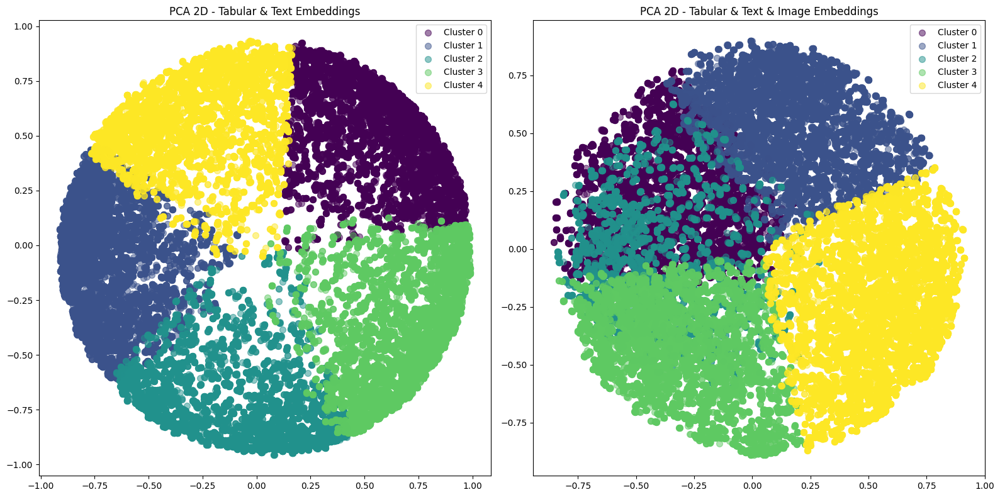

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot for text embeddings
unique_cluster_ids = np.unique(kmeans_txt_labels)
colors = cm.viridis(np.linspace(0, 1, len(unique_cluster_ids)))

for i, cluster_id in enumerate(unique_cluster_ids):
    axes[0].scatter(
        pca_txt_results[kmeans_txt_labels == cluster_id, 0],
        pca_txt_results[kmeans_txt_labels == cluster_id, 1],
        color=colors[i],
        label=f"Cluster {cluster_id}",
        s=50,
        alpha=0.5,
    )
axes[0].set_title("PCA 2D - Tabular & Text Embeddings")
axes[0].legend()

# Plot for image embeddings
unique_cluster_ids = np.unique(kmeans_txtimg_labels)

for i, cluster_id in enumerate(unique_cluster_ids):
    axes[1].scatter(
        pca_img_results[kmeans_txtimg_labels == cluster_id, 0],
        pca_img_results[kmeans_txtimg_labels == cluster_id, 1],
        color=colors[i],
        label=f"Cluster {cluster_id}",
        s=50,
        alpha=0.5,
    )
axes[1].set_title("PCA 2D - Tabular & Text & Image Embeddings")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pca_2d_clusters.png"))
plt.show()

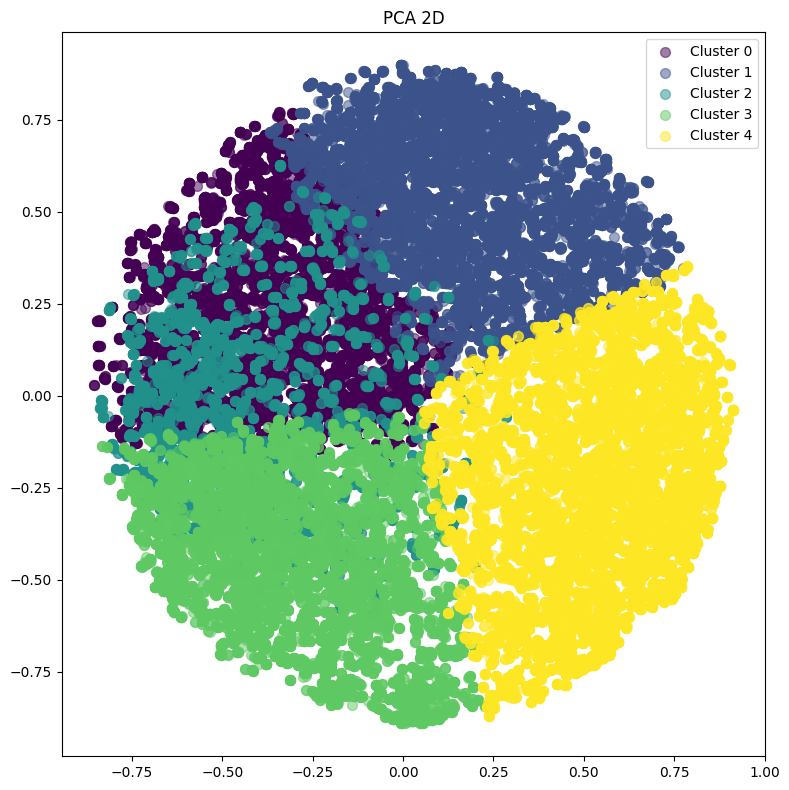

In [13]:
fig = plt.figure(figsize=(8, 8))
unique_cluster_ids = np.unique(kmeans_txtimg_labels)
colors = cm.viridis(np.linspace(0, 1, len(unique_cluster_ids)))

for i, cluster_id in enumerate(unique_cluster_ids):
    plt.scatter(
        pca_img_results[kmeans_txtimg_labels == cluster_id, 0],
        pca_img_results[kmeans_txtimg_labels == cluster_id, 1],
        color=colors[i],
        label=f"Cluster {cluster_id}",
        s=50,
        alpha=0.5,
    )
plt.title("PCA 2D")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pca_img_clusters.png"))
plt.show()

## 3D PCA Visualization

In [14]:
pca_img_3d = PCA(n_components=3, random_state=42)
pca_img_3d_results = pca_img_3d.fit_transform(full_embeddings_txtimg)

pca_txt_3d = PCA(n_components=3, random_state=42)
pca_txt_3d_results = pca_txt_3d.fit_transform(full_embeddings_txt)

In [15]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors  # To convert colors to hex

colors = [
    mcolors.rgb2hex(cm.viridis(i)) for i in np.linspace(0, 1, len(unique_cluster_ids))
]

fig = make_subplots(rows=1, cols=1, specs=[[{"type": "scatter3d"}]])


# Convert index to row and column in a 2x2 grid
row, col = divmod(0, 1)

# Create traces for each cluster
for i, cluster_id in enumerate(unique_cluster_ids):
    mask = kmeans_txtimg_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_img_3d_results[mask, 0],  # PC1
            y=pca_img_3d_results[mask, 1],  # PC2
            z=pca_img_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
        ),
        row=row + 1,
        col=col + 1,
    )

# Step 5: Set titles and layout
fig.update_layout(
    height=800,
    width=800,
    template="none",
    margin=dict(t=5, r=20, b=10, l=20),
    scene=dict(
        xaxis=dict(range=[-1, 1]),
        yaxis=dict(range=[-1, 1]),
        zaxis=dict(range=[-1, 1]),
        camera_eye=dict(x=1, y=2, z=1),
    ),
)

fig.update_layout(
    legend=dict(
        x=0.5,  # Center the legend horizontally
        y=-0.01,  # Place the legend below the plot
        xanchor="center",  # Align legend horizontally by its center
        yanchor="top",  # Align legend vertically by its top
        orientation="h",  # Arrange legend items horizontally
        bgcolor="rgba(255, 255, 255, 0.7)",  # Optional: Add a semi-transparent background
        bordercolor="black",  # Optional: Add a border
        borderwidth=1,  # Optional: Set border width
    )
)

# Step 6: Show plot
fig.show()

c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [16]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors  # To convert colors to hex

colors = [
    mcolors.rgb2hex(cm.viridis(i)) for i in np.linspace(0, 1, len(unique_cluster_ids))
]

fig = make_subplots(rows=1, cols=1, specs=[[{"type": "scatter3d"}]])


# Convert index to row and column in a 2x2 grid
row, col = divmod(0, 1)


# Create traces for each cluster
for i, cluster_id in enumerate(unique_cluster_ids):
    mask = kmeans_txt_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_txt_3d_results[mask, 0],  # PC1
            y=pca_txt_3d_results[mask, 1],  # PC2
            z=pca_txt_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
        ),
        row=row + 1,
        col=col + 1,
    )

# Step 5: Set titles and layout
fig.update_layout(
    height=800,
    width=800,
    template="none",
    margin=dict(t=5, r=20, b=10, l=20),
    scene=dict(
        xaxis=dict(range=[-1, 1]),
        yaxis=dict(range=[-1, 1]),
        zaxis=dict(range=[-1, 1]),
        camera_eye=dict(x=1, y=2, z=1),
    ),
)

fig.update_layout(
    legend=dict(
        x=0.5,  # Center the legend horizontally
        y=-0.01,  # Place the legend below the plot
        xanchor="center",  # Align legend horizontally by its center
        yanchor="top",  # Align legend vertically by its top
        orientation="h",  # Arrange legend items horizontally
        bgcolor="rgba(255, 255, 255, 0.7)",  # Optional: Add a semi-transparent background
        bordercolor="black",  # Optional: Add a border
        borderwidth=1,  # Optional: Set border width
    )
)

# Step 6: Show plot
fig.show()

In [17]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors  # To convert colors to hex

# Assuming pca_img_3d_results and pca_txt_3d_results are already computed
unique_cluster_ids_img = np.unique(kmeans_txtimg_labels)
unique_cluster_ids_txt = np.unique(kmeans_txt_labels)

colors_img = [
    mcolors.rgb2hex(cm.viridis(i))
    for i in np.linspace(0, 1, len(unique_cluster_ids_img))
]
colors_txt = [
    mcolors.rgb2hex(cm.viridis(i))
    for i in np.linspace(0, 1, len(unique_cluster_ids_txt))
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]],
    subplot_titles=(
        "Tabular & Text Embeddings",
        "Tabular & Text & Image Embeddings",
    ),  # Add subplot titles
)

# Create traces for each cluster for text embeddings
for i, cluster_id in enumerate(unique_cluster_ids_txt):
    mask = kmeans_txt_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_txt_3d_results[mask, 0],  # PC1
            y=pca_txt_3d_results[mask, 1],  # PC2
            z=pca_txt_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors_txt[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
            showlegend=True,  # Show legend only for the first subplot
        ),
        row=1,
        col=1,
    )

# Create traces for each cluster for image embeddings
for i, cluster_id in enumerate(unique_cluster_ids_img):
    mask = kmeans_txtimg_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_img_3d_results[mask, 0],  # PC1
            y=pca_img_3d_results[mask, 1],  # PC2
            z=pca_img_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors_img[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
            showlegend=False,  # Hide legend for the second subplot
        ),
        row=1,
        col=2,
    )

# Set titles and layout with camera angles
fig.update_layout(
    height=600,
    width=900,  # Adjusted figure size
    title_text="PCA 3D Cluster Visualization",
    scene_camera=dict(
        eye=dict(
            x=1.25, y=1.25, z=1.25
        )  # Adjust the camera angle for the first subplot
    ),
    scene2_camera=dict(
        eye=dict(
            x=1.25, y=1.25, z=1.25
        )  # Adjust the camera angle for the second subplot
    ),
)

# Show plot
fig.show()

In [18]:
df_full = pd.concat([df_full_train, df_full_val]).reset_index()

In [19]:
df_full

,ASIN,date,index,Q_t,PRICE,P_bb_t,text,window,REVIEW_COUNT,RATING,...,emb_246_txt,emb_247_txt,emb_248_txt,emb_249_txt,emb_250_txt,emb_251_txt,emb_252_txt,emb_253_txt,emb_254_txt,emb_255_txt
0,1947335162,2023-03-27,17,-12.515369,3.427422,3.633271,Catalyst Game Labs Battletech: Technical Reado...,28.0,62.035714,4.678571,...,2.071580,-1.122289,3.329472,1.311347,-0.395137,-1.232761,-0.243675,0.968548,-2.207878,-3.731019
1,1947335162,2023-04-24,25,-12.576837,3.400864,3.582963,Catalyst Game Labs Battletech: Technical Reado...,28.0,63.607143,4.700000,...,2.071580,-1.122289,3.329472,1.311347,-0.395137,-1.232761,-0.243675,0.968548,-2.207878,-3.731019
2,1947335162,2023-05-22,33,-12.688608,3.400864,3.587493,Catalyst Game Labs Battletech: Technical Reado...,28.0,64.000000,4.700000,...,2.071580,-1.122289,3.329472,1.311347,-0.395137,-1.232761,-0.243675,0.968548,-2.207878,-3.731019
3,1947335162,2023-06-19,41,-12.238366,3.400864,3.555062,Catalyst Game Labs Battletech: Technical Reado...,28.0,64.892857,4.700000,...,2.071580,-1.122289,3.329472,1.311347,-0.395137,-1.232761,-0.243675,0.968548,-2.207878,-3.731019
4,1947335162,2023-07-17,49,-12.362335,3.400864,3.539400,Catalyst Game Labs Battletech: Technical Reado...,28.0,65.000000,4.700000,...,2.071580,-1.122289,3.329471,1.311348,-0.395137,-1.232760,-0.243675,0.968547,-2.207878,-3.731020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68761,B0CMLQYL7H,2024-01-29,585573,-12.426648,2.771964,2.771964,wltk Movie Cars 2 3 Hauler Mack Truck NO.64 & ...,28.0,4.000000,4.150000,...,1.869226,-1.154970,3.575028,1.541332,-0.255465,-1.768585,-0.488111,1.142043,-2.097376,-3.453580
68762,B0CMLQZVT7,2024-01-29,585729,-12.379784,2.771964,2.771964,wltk Movie Cars 2 3 Hauler Truck NO.117 Ralph ...,28.0,4.000000,4.150000,...,1.867264,-1.120764,3.532469,1.574498,-0.260486,-1.675475,-0.482075,1.121368,-2.087194,-3.421260
68763,B0CMLS8KNB,2024-01-29,585885,-12.079333,2.771964,2.771964,wltk Movie Cars 2 3 Hauler Truck NO.28 & Phil ...,28.0,4.000000,4.150000,...,1.891474,-1.156627,3.577268,1.521474,-0.247597,-1.820355,-0.467071,1.185807,-2.117147,-3.436886
68764,B0CMLSH3M2,2024-01-29,586041,-12.567084,2.771964,2.771964,wltk Movie Cars 2 3 Hauler Truck NO.82 Darren ...,28.0,4.000000,4.150000,...,1.883795,-1.161186,3.558644,1.533927,-0.285088,-1.739313,-0.453925,1.172003,-2.116627,-3.417228


In [20]:
n_clusters = 5

centroids_img = cluster_centroids_txtimg
cl_img = [f"similarity_cluster_img_{i}" for i in range(n_clusters)]

centroids_txt = cluster_centroids_txt
cl_txt = [f"similarity_cluster_txt_{i}" for i in range(n_clusters)]
df_full_val.loc[:, cl_txt] = np.nan
df_full_train.loc[:, cl_txt] = np.nan
df_full.loc[:, cl_txt] = np.nan

In [21]:
from sklearn.metrics import pairwise_distances

for i_embedding, embedding in enumerate(full_embeddings_txtimg.values):
    for i, centroid in enumerate(centroids_img):
        similarity = 1.0 - pairwise_distances(
            embedding.reshape(1, -1), centroid.reshape(1, -1), metric="cosine"
        )
        df_full.loc[i_embedding, cl_img[i]] = similarity

for i_embedding, embedding in enumerate(full_embeddings_txt.values):
    for i, centroid in enumerate(centroids_txt):
        similarity = 1.0 - pairwise_distances(
            embedding.reshape(1, -1), centroid.reshape(1, -1), metric="cosine"
        )
        df_full.loc[i_embedding, cl_txt[i]] = similarity

In [22]:
n_neighbors = 4
closest_points_img = [None]
closest_points_indices_val_img = None
for embeddings, centroids, val_cluster_ids in zip(
    [full_embeddings_txtimg], [centroids_img], [kmeans_txtimg_labels]
):
    for i_embedding, embedding in enumerate([embeddings]):
        distances = pairwise_distances(embedding, centroids, metric="euclidean")
        closest_points_indices = []
        for i in range(n_clusters):
            cluster_indices = np.where(val_cluster_ids == i)[0]
            cluster_distances = distances[cluster_indices, i]
            sorted_indices = cluster_indices[np.argsort(cluster_distances)]

            closest_indices_i = []
            seen_asins = set()

            for idx in sorted_indices:
                asin = df_full.loc[idx, "ASIN"]
                if asin not in seen_asins:
                    closest_indices_i.append(idx)
                    seen_asins.add(asin)
                if len(closest_indices_i) == n_neighbors:
                    break

            closest_points_indices.append(closest_indices_i)

        closest_points_img[i_embedding] = closest_points_indices
    closest_points_indices_val = closest_points_img

closest_points_txt = [None]
closest_points_indices_val_txt = None
for embeddings, centroids, val_cluster_ids in zip(
    [full_embeddings_txt], [centroids_txt], [kmeans_txt_labels]
):
    for i_embedding, embedding in enumerate([embeddings]):
        distances = pairwise_distances(embedding, centroids, metric="euclidean")
        closest_points_indices = []
        for i in range(n_clusters):
            cluster_indices = np.where(val_cluster_ids == i)[0]
            cluster_distances = distances[cluster_indices, i]
            sorted_indices = cluster_indices[np.argsort(cluster_distances)]

            closest_indices_i = []
            seen_asins = set()

            for idx in sorted_indices:
                asin = df_full.loc[idx, "ASIN"]
                if asin not in seen_asins:
                    closest_indices_i.append(idx)
                    seen_asins.add(asin)
                if len(closest_indices_i) == n_neighbors:
                    break

            closest_points_indices.append(closest_indices_i)

        closest_points_txt[i_embedding] = closest_points_indices
    closest_points_indices_val_txt = closest_points_txt

In [23]:
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import textwrap
from IPython.display import display  # Remove if not using Jupyter Notebook

# Ensure output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

text_len = 45
try:
    font = ImageFont.truetype("arial.ttf", 22)
    font = ImageFont.truetype("arialbd.ttf", size=36)
except IOError:
    font = ImageFont.load_default()

In [24]:
from PIL import ImageFont
from datasets import Image as dsImage
from PIL import Image

data_files = {
    "train": ["train-00000-of-00002.parquet", "train-00001-of-00002.parquet"],
    "validation": [
        "validation-00000-of-00002.parquet",
        "validation-00001-of-00002.parquet",
    ],
}


ds_dict = datasets.load_dataset(
    "parquet",
    data_dir="../data/amzn_toys_monthly_diffs_ffill_fixed_splits_buybox",
    data_files=data_files,
)

ds_full = datasets.concatenate_datasets(
    [ds_dict["train"], ds_dict["validation"]]
)

ds_full = ds_full.to_pandas().set_index("ASIN")

In [25]:
df_img = df_img.set_index("ASIN")

In [ ]:
import io

for i, indices in enumerate(closest_points_img[0]):
    print(f"Cluster {i}:")
    images = []
    for idx in indices:
        asin = df_full.loc[int(idx), "ASIN"]
        try:
            text = ds_full.loc[asin, "text"][0]
        except KeyError:
            print(f"Index {idx} not found in DataFrame.")
            continue

        truncated_text = (text[:text_len] + "...") if len(text) > text_len else text
        img = Image.open(io.BytesIO(df_img.loc[asin, :].values[0]["bytes"]))

        # Adjust image size
        img = img.resize((600, 400))  # Adjust the size as needed

        # Create a new canvas for the image and text
        unit_width = 600
        unit_height = 550  # Adjust height to accommodate text
        unit_canvas = Image.new(
            "RGB", (unit_width, unit_height), color=(255, 255, 255)
        )  # White background

        # Paste the image onto the canvas
        unit_canvas.paste(img, (0, 0))

        # Draw text below the image
        draw = ImageDraw.Draw(unit_canvas)

        lines = textwrap.wrap(truncated_text, width=30)
        ascent, descent = font.getmetrics()
        line_height = ascent + descent
        y_text = img.height + 10  # Start just below the image

        for line in lines:
            draw.text((10, y_text), line, font=font, fill=(0, 0, 0))  # Black text
            y_text += line_height

        images.append(unit_canvas)

    if not images:
        print(f"No images found for Cluster {i}.")
        continue

    # Adjust the collage dimensions
    num_images = len(images)
    grid_columns = 4  # Adjust based on desired layout
    grid_rows = int(np.ceil(num_images / grid_columns))
    collage_width = unit_width * grid_columns
    collage_height = unit_height * grid_rows

    collage = Image.new(
        "RGB", (collage_width, collage_height), color=(255, 255, 255)
    )  # White background

    # Place each unit onto the collage
    for idx, img in enumerate(images):
        x = (idx % grid_columns) * unit_width
        y = (idx // grid_columns) * unit_height
        collage.paste(img, (x, y))

    # Display or save the collage
    # If using Jupyter Notebook, you can use display(collage)
    collage.show()
    collage.save(os.path.join(output_dir, f"collage_cluster_img_{i}.png"))
    print(f"Collage for Cluster (img) {i} saved successfully.\n" + "-" * 50 + "\n")

Cluster 0:


C:\Users\Work\AppData\Local\Temp\ipykernel_12312\3250326127.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Collage for Cluster (img) 0 saved successfully.
--------------------------------------------------

Cluster 1:
Collage for Cluster (img) 1 saved successfully.
--------------------------------------------------

Cluster 2:
Collage for Cluster (img) 2 saved successfully.
--------------------------------------------------

Cluster 3:
Collage for Cluster (img) 3 saved successfully.
--------------------------------------------------

Cluster 4:
Collage for Cluster (img) 4 saved successfully.
--------------------------------------------------



In [27]:
# Assuming df, ds, and closest_points are already defined
for i, indices in enumerate(closest_points_txt[0]):
    print(f"Cluster {i}:")
    images = []
    for idx in indices:
        asin = df_full.loc[int(idx), "ASIN"]
        try:
            text = ds_full.loc[asin, "text"][0]
        except KeyError:
            print(f"Index {idx} not found in DataFrame.")
            continue

        truncated_text = (text[:text_len] + "...") if len(text) > text_len else text
        img = Image.open(io.BytesIO(df_img.loc[asin, :].values[0]["bytes"]))

        # Adjust image size
        img = img.resize((600, 400))  # Adjust the size as needed

        # Create a new canvas for the image and text
        unit_width = 600
        unit_height = 550  # Adjust height to accommodate text
        unit_canvas = Image.new(
            "RGB", (unit_width, unit_height), color=(255, 255, 255)
        )  # White background

        # Paste the image onto the canvas
        unit_canvas.paste(img, (0, 0))

        # Draw text below the image
        draw = ImageDraw.Draw(unit_canvas)

        lines = textwrap.wrap(truncated_text, width=30)
        ascent, descent = font.getmetrics()
        line_height = ascent + descent
        y_text = img.height + 10  # Start just below the image

        for line in lines:
            draw.text((10, y_text), line, font=font, fill=(0, 0, 0))  # Black text
            y_text += line_height

        images.append(unit_canvas)

    if not images:
        print(f"No images found for Cluster {i}.")
        continue

    # Adjust the collage dimensions
    num_images = len(images)
    grid_columns = 4  # Adjust based on desired layout
    grid_rows = int(np.ceil(num_images / grid_columns))
    collage_width = unit_width * grid_columns
    collage_height = unit_height * grid_rows

    collage = Image.new(
        "RGB", (collage_width, collage_height), color=(255, 255, 255)
    )  # White background

    # Place each unit onto the collage
    for idx, img in enumerate(images):
        x = (idx % grid_columns) * unit_width
        y = (idx // grid_columns) * unit_height
        collage.paste(img, (x, y))

    # Display or save the collage
    # If using Jupyter Notebook, you can use display(collage)
    collage.show()
    collage.save(os.path.join(output_dir, f"collage_cluster_txt_{i}.png"))
    print(f"Collage for Cluster (txt) {i} saved successfully.\n" + "-" * 50 + "\n")

Cluster 0:


C:\Users\Work\AppData\Local\Temp\ipykernel_12312\586051905.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Collage for Cluster (txt) 0 saved successfully.
--------------------------------------------------

Cluster 1:
Collage for Cluster (txt) 1 saved successfully.
--------------------------------------------------

Cluster 2:
Collage for Cluster (txt) 2 saved successfully.
--------------------------------------------------

Cluster 3:
Collage for Cluster (txt) 3 saved successfully.
--------------------------------------------------

Cluster 4:
Collage for Cluster (txt) 4 saved successfully.
--------------------------------------------------



In [28]:
output_dir

'../output/02_cluster_centroid_products'

In [29]:
all_texts_img = {}

for i, indices in enumerate(closest_points_img[0]):
    print(f"Cluster {i}:")
    all_texts_img[i] = []
    for i_idx, idx in enumerate(indices):
        asin = df_full.loc[int(idx), "ASIN"]
        print(f"Closest point {i_idx}:")
        text = ds_full.loc[asin, "text"][0]
        all_texts_img[i].append(text)
        truncated_text = (text[:70] + "...") if len(text) > 50 else text
        print(truncated_text)
    print("\n" + "-" * 50 + "\n")

Cluster 0:
Closest point 0:
Disney Pixar Cars Nigel Gearsley | Cars & Race Cars | Disney Pixar Car...
Closest point 1:
Qcar Pickup Truck G63 Vehicles Toys, Diecast Metal Model Car Toys, Toy...
Closest point 2:
IPG for Vector Robot Face Screen Guard Decoration KIT Include Wheels&B...
Closest point 3:
Disney Car Toys and Pixar Cars Sara Wheelson, Miniature, Collectible R...

--------------------------------------------------

Cluster 1:
Closest point 0:
Bruder Mack Granite Garbage Truck (Ruby red-Green) | Trucks | Product ...
Closest point 1:
Bruder Man Tgs Side Loading Garbage Truck Vehicles-Toys | Trucks | The...
Closest point 2:
Bruder MB Sprinter Ups with Driver and Accessories Vehicles-Toys | Tru...
Closest point 3:


C:\Users\Work\AppData\Local\Temp\ipykernel_12312\1257881989.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Bruder Toys 02828 Mack Granite UPS Logistics Truck with Forklift Vehic...

--------------------------------------------------

Cluster 2:
Closest point 0:
Matchbox Dodge Charger Pursuit | Cars & Race Cars | Matchbox Dodge Cha...
Closest point 1:
Hot Wheels Lamborghini Veneno, Speed Machines Car Culture 5/5 (HKC41) ...
Closest point 2:
Matchbox 1970 Ford Ranchero 17/100 (Green) | Cars & Race Cars | 1:64 s...
Closest point 3:
Matchbox 2021 Ford Bronco 25/100 (Mint Green) | Cars & Race Cars | 1:6...

--------------------------------------------------

Cluster 3:
Closest point 0:
Kinsmart Red 1955 Chevy Stepside Pick-Up Die Cast Collectible Toy Truc...
Closest point 1:
Wooden Trains Cars with Crane Magnetic Train Toys for Wooden Train Tra...
Closest point 2:
Wooden Trains Cars with Crane Magnetic Train Toys for Wooden Train Tra...
Closest point 3:
KiNSMART 2016 Pagani Huayra White 5" 1:38 Scale Die Cast Metal Model T...

--------------------------------------------------

Cluster 4:
Closes

Cluster 0

 Action-Packed Truck and Car Sets with Compound Play and Surprise Collectibles


Cluster 1

 Realistic Heavy-Duty Vehicle and Train Playsets for Immersive Role-Play Adventures


Cluster 2

 Character-Inspired Die-Cast Race Cars Featuring Detailed, Movie-Style Designs


Cluster 3

 Authentic Miniature Autos Showcasing Classic and Modern Vehicle Models

Cluster 4


 Die-Cast Replicas of Iconic Cars and Trucks with Pull-Back Action for Dynamic Play

In [30]:
all_texts_txt = {}

for i, indices in enumerate(closest_points_img[0]):
    print(f"Cluster {i}:")
    all_texts_txt[i] = []
    for i_idx, idx in enumerate(indices):
        asin = df_full.loc[int(idx), "ASIN"]
        print(f"Closest point {i_idx}:")
        text = ds_full.loc[asin, "text"][0]
        all_texts_txt[i].append(text)
        truncated_text = (text[:70] + "...") if len(text) > 50 else text
        print(truncated_text)
    print("\n" + "-" * 50 + "\n")

Cluster 0:
Closest point 0:
Disney Pixar Cars Nigel Gearsley | Cars & Race Cars | Disney Pixar Car...
Closest point 1:
Qcar Pickup Truck G63 Vehicles Toys, Diecast Metal Model Car Toys, Toy...
Closest point 2:
IPG for Vector Robot Face Screen Guard Decoration KIT Include Wheels&B...
Closest point 3:
Disney Car Toys and Pixar Cars Sara Wheelson, Miniature, Collectible R...

--------------------------------------------------

Cluster 1:
Closest point 0:
Bruder Mack Granite Garbage Truck (Ruby red-Green) | Trucks | Product ...
Closest point 1:
Bruder Man Tgs Side Loading Garbage Truck Vehicles-Toys | Trucks | The...
Closest point 2:
Bruder MB Sprinter Ups with Driver and Accessories Vehicles-Toys | Tru...
Closest point 3:
Bruder Toys 02828 Mack Granite UPS Logistics Truck with Forklift Vehic...

--------------------------------------------------

Cluster 2:
Closest point 0:
Matchbox Dodge Charger Pursuit | Cars & Race Cars | Matchbox Dodge Cha...
Closest point 1:


C:\Users\Work\AppData\Local\Temp\ipykernel_12312\1268226048.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Hot Wheels Lamborghini Veneno, Speed Machines Car Culture 5/5 (HKC41) ...
Closest point 2:
Matchbox 1970 Ford Ranchero 17/100 (Green) | Cars & Race Cars | 1:64 s...
Closest point 3:
Matchbox 2021 Ford Bronco 25/100 (Mint Green) | Cars & Race Cars | 1:6...

--------------------------------------------------

Cluster 3:
Closest point 0:
Kinsmart Red 1955 Chevy Stepside Pick-Up Die Cast Collectible Toy Truc...
Closest point 1:
Wooden Trains Cars with Crane Magnetic Train Toys for Wooden Train Tra...
Closest point 2:
Wooden Trains Cars with Crane Magnetic Train Toys for Wooden Train Tra...
Closest point 3:
KiNSMART 2016 Pagani Huayra White 5" 1:38 Scale Die Cast Metal Model T...

--------------------------------------------------

Cluster 4:
Closest point 0:
Paw Patrol, True Metal Spark Gift Pack of 6 Collectible Die-Cast Vehic...
Closest point 1:
Smashers Monster Truck Surprise (Shark Truck) by ZURU Boys with 25 Sur...
Closest point 2:
Thomas & Friends Wooden Railway Toy Train Rosie Push-

In [31]:
all_texts_img

{0: ['Disney Pixar Cars Nigel Gearsley | Cars & Race Cars | Disney Pixar Cars 3 characters are rolling in! This exciting assortment of new 1:55 scale vehicles offers huge variety with true to movie details. Start or expand your collection with these big personality wheels, from Lightning McQueen, Cruz Ramirez to Jackson Storm and all of the favorite big screen wheels in between! Each sold separately, subject to availability. | New 1:55 scale character vehicles from Disney Pixar Cars3! | Authentic, movie inspired designs and details that highlight each personality. | Wide variety torecreate all the Cars movie adventuresor enhance your collection. | Eachdie-cast sold separately, subject to availability. | nan | Mattel | Disney Cars Toys | Toy | FLM25 | nan | nan | nan',
  "Qcar Pickup Truck G63 Vehicles Toys, Diecast Metal Model Car Toys, Toy Trucks for Kids | Trucks | nan | SIMPLE AND FUN: Our Pickup Truck car toys set with a motorcycle have no complicated functions, they are simple and

In [32]:
all_texts_txt

{0: ['Disney Pixar Cars Nigel Gearsley | Cars & Race Cars | Disney Pixar Cars 3 characters are rolling in! This exciting assortment of new 1:55 scale vehicles offers huge variety with true to movie details. Start or expand your collection with these big personality wheels, from Lightning McQueen, Cruz Ramirez to Jackson Storm and all of the favorite big screen wheels in between! Each sold separately, subject to availability. | New 1:55 scale character vehicles from Disney Pixar Cars3! | Authentic, movie inspired designs and details that highlight each personality. | Wide variety torecreate all the Cars movie adventuresor enhance your collection. | Eachdie-cast sold separately, subject to availability. | nan | Mattel | Disney Cars Toys | Toy | FLM25 | nan | nan | nan',
  "Qcar Pickup Truck G63 Vehicles Toys, Diecast Metal Model Car Toys, Toy Trucks for Kids | Trucks | nan | SIMPLE AND FUN: Our Pickup Truck car toys set with a motorcycle have no complicated functions, they are simple and